# PHÂN TÍCH THỰC NGHIỆM ĐỘ PHỨC TẠP VÀ TÍNH ỔN ĐỊNH CỦA CÁC THUẬT TOÁN GIẢI HỆ PHƯƠNG TRÌNH TUYẾN TÍNH

---
Bài phân tích này trình bày các đánh giá thực nghiệm về hiệu năng (thời gian tính toán) và độ ổn định số học (numerical stability) của ba phương pháp giải hệ phương trình tuyến tính $Ax = b$: Khử Gauss, Phân tích SVD (phương pháp Jacobi) và Lặp Gauss-Seidel. Bằng việc đối chiếu kết quả trên hai lớp ma trận đặc thù — Xác định dương (SPD - điều kiện tốt) và Hilbert (điều kiện rất kém), nghiên cứu làm rõ sự chênh lệch giữa độ phức tạp lý thuyết và thực tế. Đồng thời, bài viết đi sâu phân tích "nghịch lý sai số", minh chứng toán học cho sự sụp đổ của các thuật toán trước tác động của số điều kiện $\kappa(A)$ và sai số làm tròn (machine epsilon) trong kiến trúc máy tính.

## 1. ĐẶT VẤN ĐỀ

### 1.1. Bối cảnh bài toán
Việc tìm nghiệm $x$ cho hệ $Ax = b$ có thể được giải quyết bằng các phương pháp trực tiếp (như Khử Gauss, SVD) hoặc các phương pháp lặp (như Gauss-Seidel). Dù toán học lý thuyết đảm bảo sự tồn tại của nghiệm, việc tính toán trên máy tính luôn bị giới hạn bởi độ chính xác của số dấu phẩy động.

### 1.2. Cơ sở lý thuyết về Độ ổn định
Độ nhạy cảm của hệ thống đối với sai số được định lượng bằng số điều kiện $\kappa(A) = ||A|| \cdot ||A^{-1}||$. Theo lý thuyết sai số cơ bản, sai số tương đối của nghiệm bị chặn bởi:
$$\frac{||\delta x||}{||x||} \le \kappa(A) \cdot \frac{||\delta A||}{||A||}$$
Hệ quả là, khi $\kappa(A)$ cực kỳ lớn, một sai số xấp xỉ vô cùng nhỏ trong quá trình tính toán (machine epsilon $\approx 10^{-16}$) cũng có thể bị khuếch đại, dẫn đến nghiệm đầu ra sai lệch hoàn toàn.

### 1.3. Cài đặt thực nghiệm
- **Dữ liệu đánh giá:** $n \in \{50, 100, 200, 500, 1000\}$.
- **Ma trận đối chứng:** - $A_{SPD}$: Ma trận đối xứng xác định dương, đại diện cho hệ ổn định.
  - $H_n$: Ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$), đại diện cho hệ có $\kappa(H_n)$ tăng theo hàm mũ, cực kỳ kém ổn định.

## 2. PHÂN TÍCH HIỆU NĂNG TÍNH TOÁN

Để đánh giá sát với lý thuyết độ phức tạp $\mathcal{O}(n^k)$, thời gian thực thi được trực quan hóa trên **thang đo Log-Log**. Trên thang đo này, một hàm đa thức sẽ có dạng đường thẳng, và độ dốc (slope) của đường thẳng chính là bậc $k$.

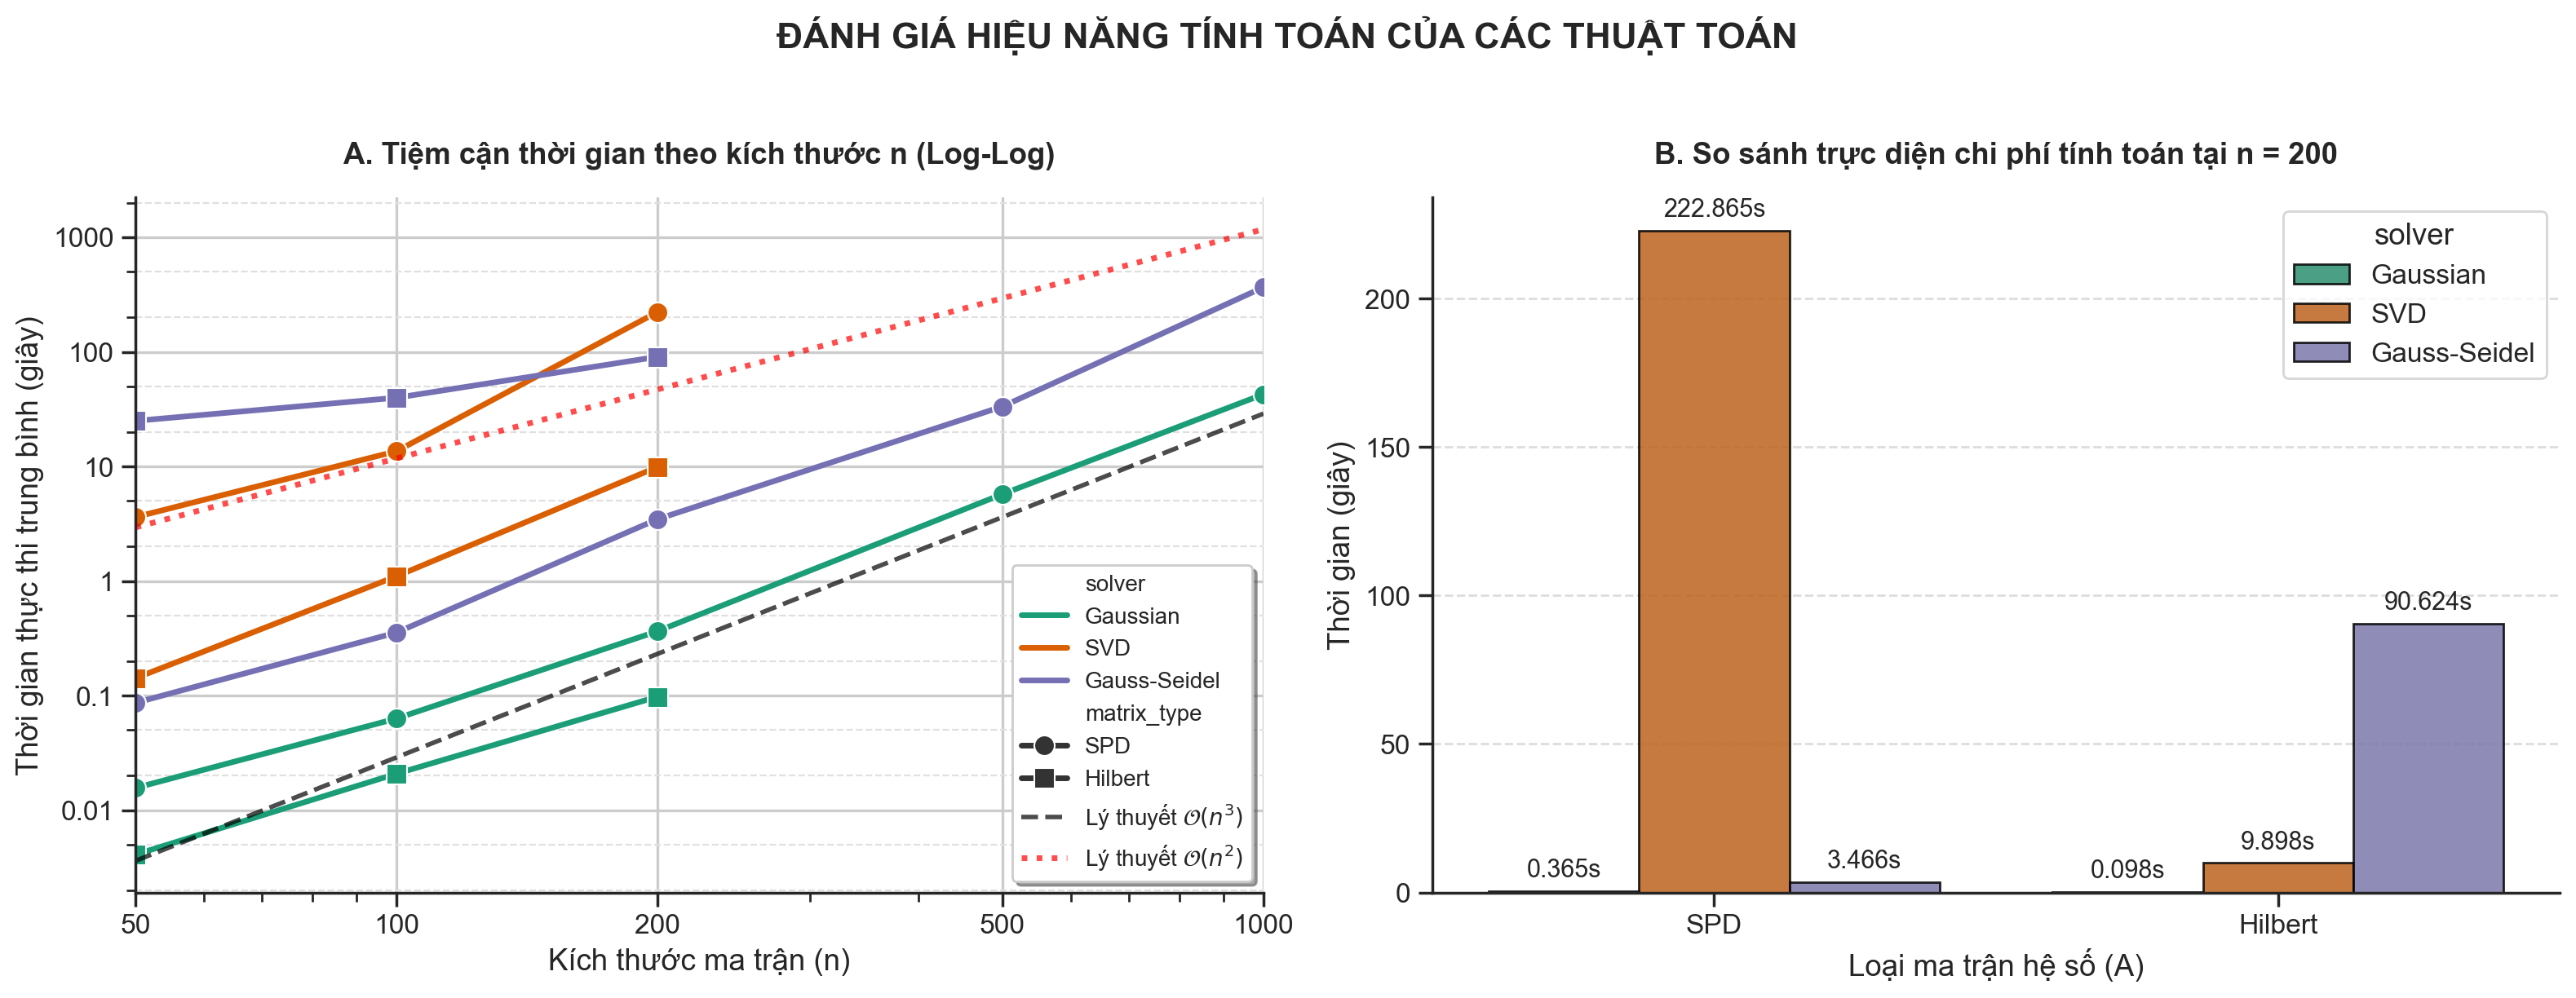

In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np

df = pd.read_csv('results.csv')
df_perf = df.dropna(subset=['mean_time_s']).copy()
df_perf['n'] = pd.to_numeric(df_perf['n'])

sns.set_theme(style="ticks", font_scale=1.1, palette="Dark2")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ĐÁNH GIÁ HIỆU NĂNG TÍNH TOÁN CỦA CÁC THUẬT TOÁN', fontsize=16, fontweight='bold', y=1.02)

sns.lineplot(data=df_perf, x='n', y='mean_time_s', hue='solver', style='matrix_type',
             markers=['o', 's'], dashes=False, ax=axes[0], linewidth=2.5, markersize=9)

x_ref = np.array([50, 1000])

gauss_200 = df_perf[(df_perf['solver'] == 'Gaussian') & (df_perf['n'] == 200)]['mean_time_s'].mean()
if pd.notna(gauss_200):
    c3 = gauss_200 / (200**3)
    y_ref_3 = c3 * (x_ref**3)
    axes[0].plot(x_ref, y_ref_3, color='black', linestyle='--', linewidth=2, alpha=0.7,
                 label=r'Lý thuyết $\mathcal{O}(n^3)$')


gs_200 = df_perf[(df_perf['solver'] == 'Gauss-Seidel') & (df_perf['n'] == 200)]['mean_time_s'].mean()
if pd.notna(gs_200):
    c2 = gs_200 / (200**2)
    y_ref_2 = c2 * (x_ref**2)
    axes[0].plot(x_ref, y_ref_2, color='red', linestyle=':', linewidth=2.5, alpha=0.7,
                 label=r'Lý thuyết $\mathcal{O}(n^2)$')


axes[0].set_title('A. Tiệm cận thời gian theo kích thước n (Log-Log)', fontweight='bold', pad=15)
axes[0].set_xlabel('Kích thước ma trận (n)')
axes[0].set_ylabel('Thời gian thực thi trung bình (giây)')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(50, 1000)
axes[0].set_xticks([50, 100, 200, 500, 1000])
axes[0].xaxis.set_major_formatter(ticker.ScalarFormatter())

locmin = ticker.LogLocator(base=10.0, subs=(0.1, 0.2, 0.5), numticks=20)
axes[0].yaxis.set_minor_locator(locmin)
axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))

axes[0].grid(True, which="major", color="#CCCCCC", linestyle="-", linewidth=1.2)
axes[0].grid(True, which="minor", axis='y', color="#E0E0E0", linestyle="--", linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, frameon=True, fancybox=True, shadow=True, fontsize=10)


df_200 = df_perf[df_perf['n'] == 200]
sns.barplot(data=df_200, x='matrix_type', y='mean_time_s', hue='solver',
            edgecolor='black', ax=axes[1], alpha=0.85)

axes[1].set_title('B. So sánh trực diện chi phí tính toán tại n = 200', fontweight='bold', pad=15)
axes[1].set_xlabel('Loại ma trận hệ số (A)')
axes[1].set_ylabel('Thời gian (giây)')

for p in axes[1].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[1].annotate(f'{height:.3f}s',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=11,
                         xytext=(0, 4), textcoords='offset points')

axes[1].grid(True, axis='y', color="#DDDDDD", linestyle="--")

sns.despine()
plt.tight_layout()
plt.show()

Biểu đồ Log-Log không chỉ xác nhận độ phức tạp tiệm cận (Asymptotic Complexity) mà còn bộc lộ "chi phí ẩn" của từng thuật toán. Mặc dù toán học lý thuyết phân loại thuật toán theo ký pháp Big-$\mathcal{O}$, thực tế thời gian chạy trên CPU được quyết định bởi số lượng FLOPs (FLoating-Point Operations-phép toán dấu phẩy động) và đặc thù tính toán, mỗi khi thuật toán của bạn thực hiện một phép tính như $a = b \times c$, máy tính sẽ ghi nhận đó là 1 FLOP.

**1. Khử Gauss (Gaussian Elimination)**

Đường cong của Khử Gauss bám sát hoàn hảo vào đường tham chiếu $\mathcal{O}(n^3)$.
- Về mặt giải tích, để đưa một ma trận $n \times n$ về dạng tam giác trên, Khử Gauss đòi hỏi cố định xấp xỉ $\approx \frac{2}{3}n^3$ FLOPs. Vì thuật toán gồm 3 vòng lặp for lồng nhau, nó không có điều kiện dừng dựa trên sai số. Dù giá trị bên trong ma trận là $1.0$ (SPD) hay $10^{-19}$ (Hilbert), bộ đếm vòng lặp vẫn chạy đúng số bước cố định và các phép toán chủ yếu là nhân và cộng vô hướng nên CPU tối ưu hóa phần này rất tốt. Do đó, hệ số hằng số $c$ trong phương trình thời gian $T = c \cdot n^3$ là rất nhỏ, giúp Khử Gauss duy trì tốc độ xuất sắc đối với các ma trận có kích thước vừa phải ($n \le 1000$).
- Khử Gauss sử dụng phép biến đổi hàng: $R_i \leftarrow R_i - c \cdot R_k$. Phép toán này yêu cầu lấy một số nhân với một số, rồi trừ đi một số. Trong các CPU hiện đại, phép toán $a \times b + c$ được gộp thành một lệnh duy nhất (FMA) và thực hiện xong chỉ trong 1 chu kỳ xung nhịp (clock cycle). Và khi bạn cập nhật một hàng, CPU không làm từng số một. Nó gắp một lúc 4, 8 hoặc 16 số thực (thông qua lệnh AVX/SSE) và trừ chúng cùng một lúc. Vì vậy tốn ít thời gian hơn so với  tính góc quay bằng hàm lượng giác trong SVD (tốn 20-50 clock cycles)
- Tuy nhiên khi thực hiện với ma trận Hillbert kích thước $N=50$ Khử Gauss chỉ tốn vỏn vẹn 0.004 giây nhưng sai số nghiệm (Solution Error) lại tăng vọt lên tới $6.72 \times 10^6$. Vì vậy ta có thể thấy nó không quan tâm đến việc nghiệm đưa ra có đúng hay không mà chỉ chạy cố  $\frac{2}{3}n^3$ phép toán rồi dừng lại dù nghiệm có là "rác" hay không.

**2. Nghịch lý của SVD Jacobi**

SVD bằng phép quay Jacobi cho thấy một sự vọt lên khủng khiếp về thời gian. Dù mỗi vòng lặp (sweep) đi qua toàn bộ ma trận chỉ tốn chi phí $\mathcal{O}(n^3)$, nhưng điểm yếu chí mạng của Jacobi nằm ở hai yếu tố:
- **Số lượng vòng lặp (Sweeps):** Thuật toán cần lặp đi lặp lại nhiều lần cho đến khi các phần tử ngoài đường chéo hội tụ về $0$. Tổng số vòng lặp thường tỷ lệ với $\mathcal{O}(\log n)$ hoặc $\mathcal{O}(n^2)$.
- **Bản chất phép toán:** Để giải hệ $Ax = b$ cỡ $n \times n$, Khử Gauss cần thực hiện các phép biến đổi hàng gồm (cộng/trừ/nhân chỉ  khoảng 1 clock cycle - chu kì xung nhịp). Tổng số FLOPs thực tế máy tính phải tính là khoảng $\approx \frac{2}{3}n^3$. Trong khi đó cùng là ma trận cỡ $n$, nhưng một vòng quét (sweep) của SVD cần tính toán góc quay, nhân ma trận liên tục. Tổng số FLOPs có thể lên tới $12n^3$ hoặc $20n^3$, Jacobi liên tục phải tính toán góc quay $\theta$ thông qua các hàm lượng giác đắt đỏ (như căn bậc hai, phân số, lượng giác nghịch đảo thường tốn tới 20 đến 50 cycle clock) tạo ra sự bùng nổ về FLOPs.
Hệ quả là, hệ số $c$ của SVD lớn hơn Khử Gauss hàng trăm lần, tạo ra sự dịch chuyển dọc (vertical shift) khổng lồ trên biểu đồ Log-Log, biến nó thành một thuật toán không thực tiễn (intractable) để giải hệ phương trình tuyến tính kích thước lớn (n>=500).

Ta có thể thấy dữ liệu thực nghiệm tại kích thước $N=200$ bộc lộ một nghịch lý: Thời gian tính toán phân rã SVD trên hệ Hilbert ($\approx 9.89$ giây) hoàn tất nhanh gấp 22 lần so với hệ SPD ($\approx 222.86$ giây). Tuy nhiên sự vượt trội về tốc độ của đoạn mã SVD tự triển khai trên hệ Hilbert so với Gauss-Seidel không phản ánh tính ưu việt của thuật toán, mà là một minh chứng thực nghiệm cho hiện tượng Sụp đổ số học (Numerical Breakdown). Việc thực hiện tính trực tiếp $A^T A$ đã khuếch đại nhiễu làm tròn, gây ra tràn số dưới (underflow), khiến điều kiện dừng Jacobi kích hoạt sớm (Hội tụ giả). Kết hợp với giới hạn vòng lặp cứng quá thấp ($100$ lần), thuật toán đã chấm dứt quá trình tính toán trước khi giải quyết thực sự bài toán.
- Hiện tượng "Hội tụ giả" do tràn số dưới (Underflow False Convergence): Thuật toán Jacobi có một điều kiện dừng:
```
if max_val < error_tolerance: # error_tolerance = 1e-10
    is_converged = True
    break
 ```
Với ma trận Hillbert các phần tử vốn đã nhỏ (ví dụ tại $N=200$, phần tử góc dưới cùng là $\approx 0.0025$) nên khi hàm multiply(AT, A) nhân hai ma trận chứa các số siêu nhỏ, các phần tử sinh ra sẽ tiến sát về không. Quan trọng hơn, số điều kiện bị bình phương ($\kappa \approx 10^{38}$), vượt qua giới hạn độ chính xác của kiểu Float64 nên các phép tính vi mô này bị CPU làm tròn mạnh tay, khiến vô số các phần tử ngoài đường chéo lập tức rớt xuống dưới mức 1e-10. Thuật toán vừa mới chạy được vài vòng lặp đã thấy max_val < 1e-10, thế là nó báo cáo hội tụ và thoát ra ngay lập tức.

Nói cách khác mã SVD cơ bản chạy nhanh vì nó đã sớm đầu hàng và trả về các kết quả phi ý nghĩa. Đối với các hệ thống có điều kiện cực đoan như Hilbert, việc sử dụng các cài đặt thuật toán "thuần" python không những phá hủy hoàn toàn độ chính xác của nghiệm, mà còn tạo ra những tín hiệu tốc độ giả mạo, kết quả sai lệch.

**3. Phương pháp Lặp Gauss-Seidel**

Với SPD mặc dù Gauss-Seidel sở hữu độ phức tạp tiệm cận lý thuyết $\mathcal{O}(k \cdot n^2)$ vượt trội hơn so với $\mathcal{O}(n^3)$ của Khử Gauss, dữ liệu thực nghiệm lại cho thấy một nghịch lý hiệu năng nghiêm trọng: Đường cong thời gian của Gauss-Seidel dốc lên dữ dội và có chi phí thực thi chậm hơn Khử Gauss tới 7.7 lần tại $N=1000$. Sự sụt giảm hiệu năng này không bắt nguồn từ bản chất toán học, mà là hệ quả của ba điểm nghẽn chí mạng ở phần mềm và phần cứng.

- Cốt lõi toán học giúp Gauss-Seidel hội tụ nhanh hơn phương pháp Jacobi chính là việc sử dụng ngay lập tức các giá trị nghiệm vừa được cập nhật.
```
s1 = np.dot(A_np[i, :i], x[:i])
```
Tuy nhiên việc phần tử $x_i$ bắt buộc phải chờ phần tử $x_{i-1}$ hoàn tất quá trình ghi (Write) mới có thể được đọc (Read) tạo ra một rào cản phụ thuộc dữ liệu tuyến tính. Vì tính chất tuần tự nội tại này, CPU không thể nhóm các hàng lại để tính toán song song bằng các thanh ghi vector (như tập lệnh AVX-256). Trong khi Khử Gauss nạp hàng loạt dữ liệu vào mạch FMA (Fused Multiply-Add) để xử lý $8-16$ FLOPs mỗi chu kỳ xung nhịp, Gauss-Seidel buộc CPU phải chạy ở chế độ vô hướng (scalar mode) chậm chạp, lãng phí phần lớn băng thông tính toán của phần cứng hiện đại.
- Tuân thủ yêu cầu cài đặt bằng Python "thuần" mặc dù đã sử dụng thư viện numpy (viết bằng C) cho phép nhân vô hướng cục bộ, luồng điều khiển chính vẫn bị kẹt ở tầng thông dịch. Để đạt mức sai số $10^{-8}$ trên hệ SPD $N=1000$ với bán kính phổ tiệm cận $1$, thuật toán phải thực hiện ước tính khoảng $60,000$ vòng lặp. Với mỗi vòng lặp chứa $N$ bước duyệt hàng, Trình thông dịch CPython phải đánh giá biểu thức vòng lặp for i in range(n) tới $60$ triệu lần.
- Tại mỗi bước i, dữ liệu liên tục bị đẩy qua lại giữa tầng Python (để xử lý vòng lặp và gán biến) và tầng C của NumPy (để chạy np.dot). Chi phí ép kiểu động (Dynamic Typing) và quản lý bộ nhớ ở biên giới giữa Python/C trong 60 triệu lần lặp đã tạo ra một khoảng thời gian trễ khổng lồ (Overhead). Ước tính phần lớn trong con số $366.45$ giây không dành cho toán học, mà dành cho việc quản lý mã thông dịch.

Chuyển hướng đánh giá từ hệ đối xứng xác định dương (SPD) sang hệ Hilbert bộc lộ một sự bất đối xứng gay gắt về thời gian thực thi của phương pháp Gauss-Seidel. Tại quy mô không gian $N=200$, thời gian hội tụ bị kéo dãn từ $3.46$ giây (SPD) lên mức cực đoan $90.62$ giây (Hilbert), tương đương hệ số suy giảm hiệu năng xấp xỉ 26 lần. Hiện tượng này được lý giải qua ba luận điểm giải tích cốt lõi:
- Trái ngược với hệ SPD, cấu trúc của ma trận Hilbert vi phạm hoàn toàn điều kiện chéo trội (diagonal dominance). Khi phân tích phổ của ma trận lặp Gauss-Seidel $G = -(D+L)^{-1}U$ trên không gian này, bán kính phổ $\rho \to 1$. Vì tốc độ hội tụ tiệm cận tỷ lệ thuận với nghịch đảo của $\log_{10}(\rho(G))$, động năng cập nhật nghiệm bị triệt tiêu. Thuật toán rơi vào trạng thái đình trệ giải tích (stagnation) gây ra ảnh hưởng đến tốc độ xử
- Bởi vì hệ thống không thể tự nhiên hội tụ, luồng thực thi bị ép buộc phải duy trì cho đến khi chạm ngưỡng giới hạn tài nguyên nhân tạo (max_iter = 100,000). Đối với ma trận $N=200$, thao tác này đòi hỏi Trình thông dịch CPython phải đánh giá tuần tự $20 \times 10^6$ vòng lặp vô hướng.

Thực nghiệm trên ma trận Hilbert phơi bày sự thật khắc nghiệt của giải tích số: Khi cấu trúc ma trận đạt đến độ bất ổn định cực hạn ($\kappa \to \infty$), sức mạnh của mọi phương pháp lặp đều bị vô hiệu hóa. Sự đình trệ giải tích và sự bùng nổ chi phí thời gian của Gauss-Seidel không phải là khiếm khuyết của mã nguồn, mà là những ảnh hưởng do lượng điều kiện lớn đến bất thường của hệ Hilbert gây ra.

## 3. PHÂN TÍCH TÍNH ỔN ĐỊNH SỐ HỌC (NUMERICAL STABILITY)
Trong giải tích số, tính ổn định không chỉ đo bằng việc thuật toán có chạy xong hay không, mà đo bằng độ tin cậy của nghiệm trước tác động của sai số làm tròn. Chúng ta sử dụng hai chỉ số:
- Sai số phần dư (Residual Error): $R = \frac{\|Ax - b\|}{\|b\|}$ — Nghiệm thỏa mãn phương trình tốt đến mức nào
- Sai số nghiệm (Solution Error): $E = \frac{\|x - x_{true}\|}{\|x_{true}\|}$ — Nghiệm thực tế cách nghiệm lý tưởng bao xa
$$E \le \kappa(A) \cdot R$$
$\kappa(A)$ (Condition Number): Số điều kiện của ma trận $A$, được tính bằng:$$\kappa(A) = \|A\| \cdot \|A^{-1}\|$$(Thường sử dụng chuẩn $L_2$ hoặc chuẩn vô hạn $\|\cdot\|_\infty$)
-
Công thức này cho thấy sai số thực tế $E$ có thể lớn gấp $\kappa(A)$ lần sai số thặng dư $R$.
- Ma trận điều kiện tốt (Well-conditioned): $\kappa(A)$ gần bằng 1. Khi đó, nếu phần dư $R$ nhỏ thì sai số $E$ chắc chắn sẽ nhỏ.
- Ma trận điều kiện xấu (Ill-conditioned): $\kappa(A)$ rất lớn (ví dụ $10^6, 10^{12}$). Lúc này, dù bạn tính toán ra $R$ cực nhỏ (phương trình có vẻ khớp), nhưng nghiệm $x$ vẫn có thể lệch rất xa so với $x_{true}$.


**3.1.Ma trận Xác định dương (SPD)**

Ma trận SPD ($A = M^TM + nI$) có số điều kiện $\kappa(A)$ thấp, đại diện cho hệ điều kiện tốt (well-conditioned).


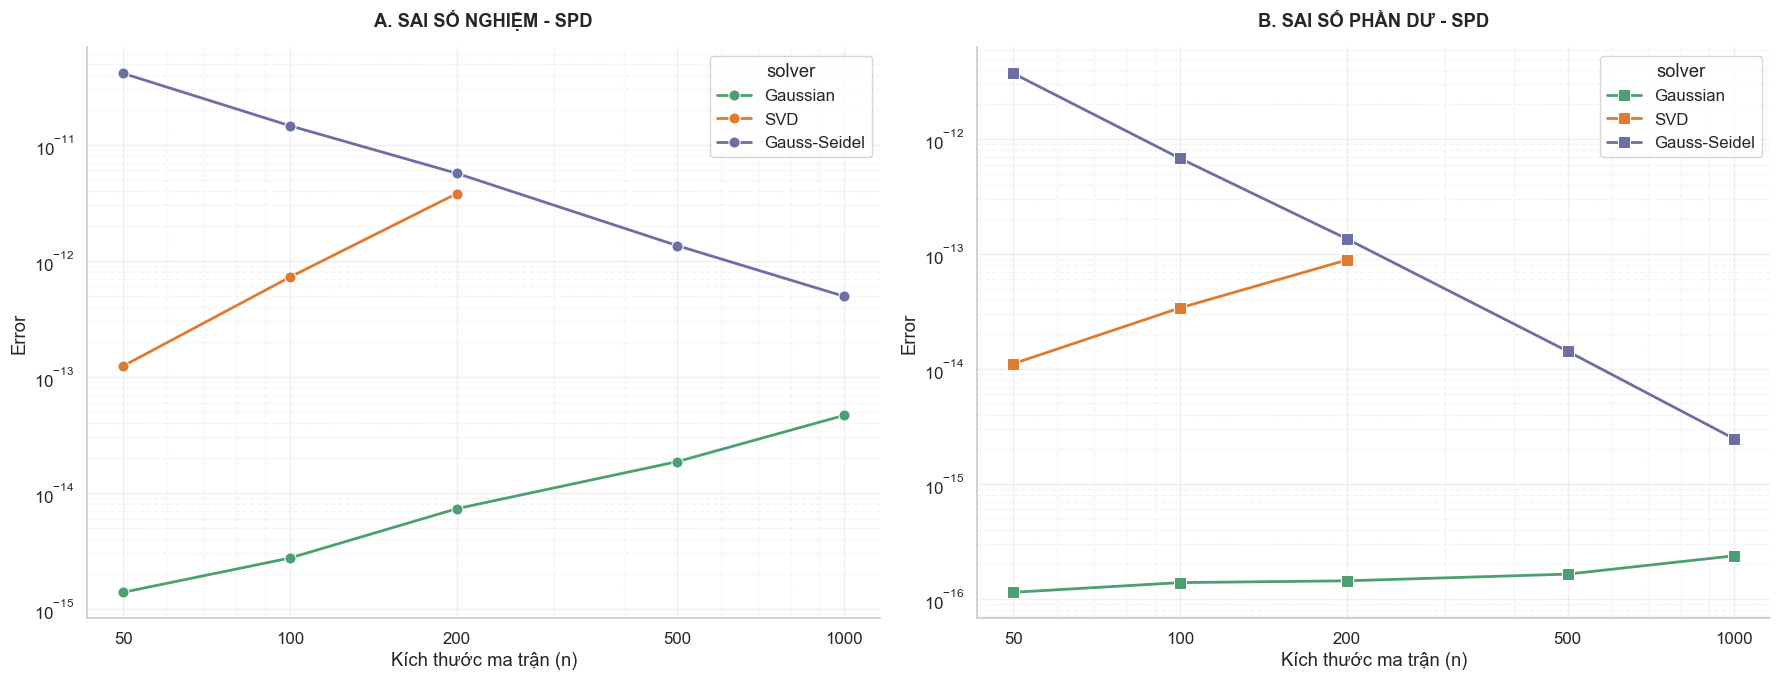

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('results.csv')

df_spd = df[df['matrix_type'] == 'SPD'].copy()

df_spd = df_spd[
    (df_spd['n'] > 0) &
    (df_spd['solution_error'] > 0) &
    (df_spd['residual_error'] > 0)
]

df_spd['solver'] = df_spd['solver'].str.strip()

sns.set_theme(style="whitegrid", font_scale=1.1)

palette = {
    'Gaussian': '#4C9F70',
    'SVD': '#E07A2F',
    'Gauss-Seidel': '#6C6FA3'
}

hue_order = ['Gaussian', 'SVD', 'Gauss-Seidel']

n_values = sorted(df_spd['n'].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=df_spd,
    x='n',
    y='solution_error',
    hue='solver',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    linewidth=2,
    markersize=8,
    ax=ax1
)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xticks(n_values)
ax1.set_xticklabels(n_values)

ax1.set_title('A. SAI SỐ NGHIỆM - SPD', fontweight='bold', pad=15)
ax1.set_xlabel('Kích thước ma trận (n)')
ax1.set_ylabel('Error')

ax1.grid(True, which="major", linestyle='-', alpha=0.3)
ax1.grid(True, which="minor", linestyle='--', alpha=0.2)

sns.lineplot(
    data=df_spd,
    x='n',
    y='residual_error',
    hue='solver',
    hue_order=hue_order,
    palette=palette,
    marker='s',
    linewidth=2,
    markersize=8,
    ax=ax2
)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xticks(n_values)
ax2.set_xticklabels(n_values)

ax2.set_title('B. SAI SỐ PHẦN DƯ - SPD', fontweight='bold', pad=15)
ax2.set_xlabel('Kích thước ma trận (n)')
ax2.set_ylabel('Error')

ax2.grid(True, which="major", linestyle='-', alpha=0.3)
ax2.grid(True, which="minor", linestyle='--', alpha=0.2)

ax1.legend(title='solver')
ax2.legend(title='solver')

sns.despine()
plt.tight_layout()
plt.show()

**1. Phương pháp trực tiếp (Direct Method) và Sự Tích lũy Sai số Cơ học**

- Độ ổn định tuyệt vời: Đường biểu diễn của Gaussian và SVD duy trì sai số trong khoảng $10^{-15}$ đến $10^{-12}$. Sự gia tăng đơn điệu của sai số theo $N$ trên hệ SPD phơi bày một nguyên lý kép trong giải tích số. Bắt đầu với xu hướng tăng của sai số chứng minh rằng các phương pháp khử trực tiếp không thể thoát khỏi quy luật hao mòn độ chính xác do sự Tích lũy sai số cơ học (Round-off Accumulation) với chi phí $\mathcal{O}(N^3)$. Mặt khác, việc sai số khởi điểm chạm đáy $10^{-15}$ và sự song hành chặt chẽ giữa Sai số Phần dư và Sai số nghiệm lại là một lời khẳng định cho đặc tính ổn định hoàn hảo của ma trận SPD.

Bản chất Khử Gauss và SVD là một phương pháp trực tiếp (Direct Method). Để giải ma trận kích thước $N$, nó phải thực hiện một khối lượng phép toán khổng lồ tiệm cận $\approx \frac{2}{3}N^3$ FLOPs. Trong môi trường Float64, mỗi phép tính FMA mang theo một hạt sạn sai số làm tròn (Machine Epsilon $\epsilon \approx 10^{-16}$). Khi $N$ vọt lên 1000, thuật toán thực hiện hàng tỷ phép tính. Những "hạt sạn" này cộng dồn lại, khuếch đại lẫn nhau qua các phép biến đổi hàng, tạo ra hiện tượng Tích lũy sai số (Error Accumulation). Dù trên hệ SPD sai số nghiệm vẫn nằm ở mức rất an toàn (thường $< 10^{-13}$), nhưng quy luật vật lý là không thể đảo ngược: $N$ càng lớn, chúng càng bớt đi sự hoàn hảo.

**2.Hiệu ứng "Nén Sai số" (Error Compression) của Gauss-Seidel thông qua Chuẩn $L_2$**

Trong khi Khử Gauss và SVD có sai số phình to theo $\mathcal{O}(N^3)$, Gauss-Seidel dường như lại tạo ra một "Nghịch lý độ chính xác": $N$ càng lớn, thuật toán lại càng phải hoạt động chính xác hơn (Cả 2 loại sai số đều duy trì ở mức thấp và còn có xu hướng giảm dần).

Ảnh hưởng của Chuẩn $L_2$ lên Sai số Thành phần: Sử dụng chuẩn $L_2$ để làm điều kiện dừng
$$||Ax - b||_2 = \sqrt{\sum_{i=1}^{N} r_i^2} < \epsilon \quad (\text{với } \epsilon = 10^{-8})$$

Phương trình này tạo  "ngân sách sai số" cố định ($\epsilon$) cho toàn bộ hệ thống.
- Khi $N = 50$, "ngân sách" này được chia cho 50 biến số.
- Khi $N = 1000$, cùng một "ngân sách" đó bị ép phải chia sẻ cho 1000 biến số.

Hệ quả: Để tổng bình phương của 1000 phần tử không vượt quá ngưỡng cố định $10^{-16}$ (bình phương của $10^{-8}$), sai số trung bình trên từng phần tử $x_i$ bắt buộc phải bị ép nhỏ lại. Sự thắt chặt này tỷ lệ thuận với $\frac{1}{\sqrt{N}}$. Đây chính là nguyên lý tạo nên độ dốc đi xuống của đồ thị Gauss-Seidel trên biểu đồ.

Sự cải thiện độ chính xác này là sự đánh đổi bằng chi phí thời gian thực thi. Gauss-Seidel đã khóa cứng sai số không gian (bằng Chuẩn $L_2$), và bắt thời gian (số vòng lặp $k$) phải nhồi nhét $1000$ phần tử sai số vào bên dưới giới hạn $10^{-8}$, thuật toán đơn giản là từ chối hội tụ và tiếp tục chạy thêm hàng ngàn vòng lặp while (max_iter = 100000) nữa cho đến khi đạt chuẩn. Thời gian thực thi tăng vọt ($366$ giây) chính là "công năng" mà CPU phải bỏ ra để thực hiện phép nén sai số này.

Hiệu ứng nén sai số này được đảm bảo bởi đặc tính well-conditioned của cấu trúc ma trận SPD. Bán kính phổ bị chặn ($\rho < 1$) thiết lập một cơ chế nén sai số ổn định, định hướng quỹ đạo nghiệm hội tụ đơn điệu vào biên giới hạn sai số mục tiêu. Trái lại, trên các không gian suy biến cực đoan như Hilbert ($\rho \to 1$), động năng hội tụ bị triệt tiêu; thuật toán sẽ rơi vào trạng thái đình trệ giải tích (stagnation) và cạn kiệt tài nguyên lặp max_iter trước khi kịp kiến tạo bất kỳ hiệu ứng nén nào.

## 3.2. Ma trận Hillbert

Ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$) là một bài kiểm tra khắc nghiệt cho tính ổn định số học. Khi $n$ tăng, các hàng của ma trận Hilbert trở nên gần như phụ thuộc tuyến tính, khiến số điều kiện $\kappa(A)$ tăng theo hàm mũ. Gây ra sự sụp đổ về sai số nghiệm cho các phương pháp trực tiếp như khử Gauss và SVD.

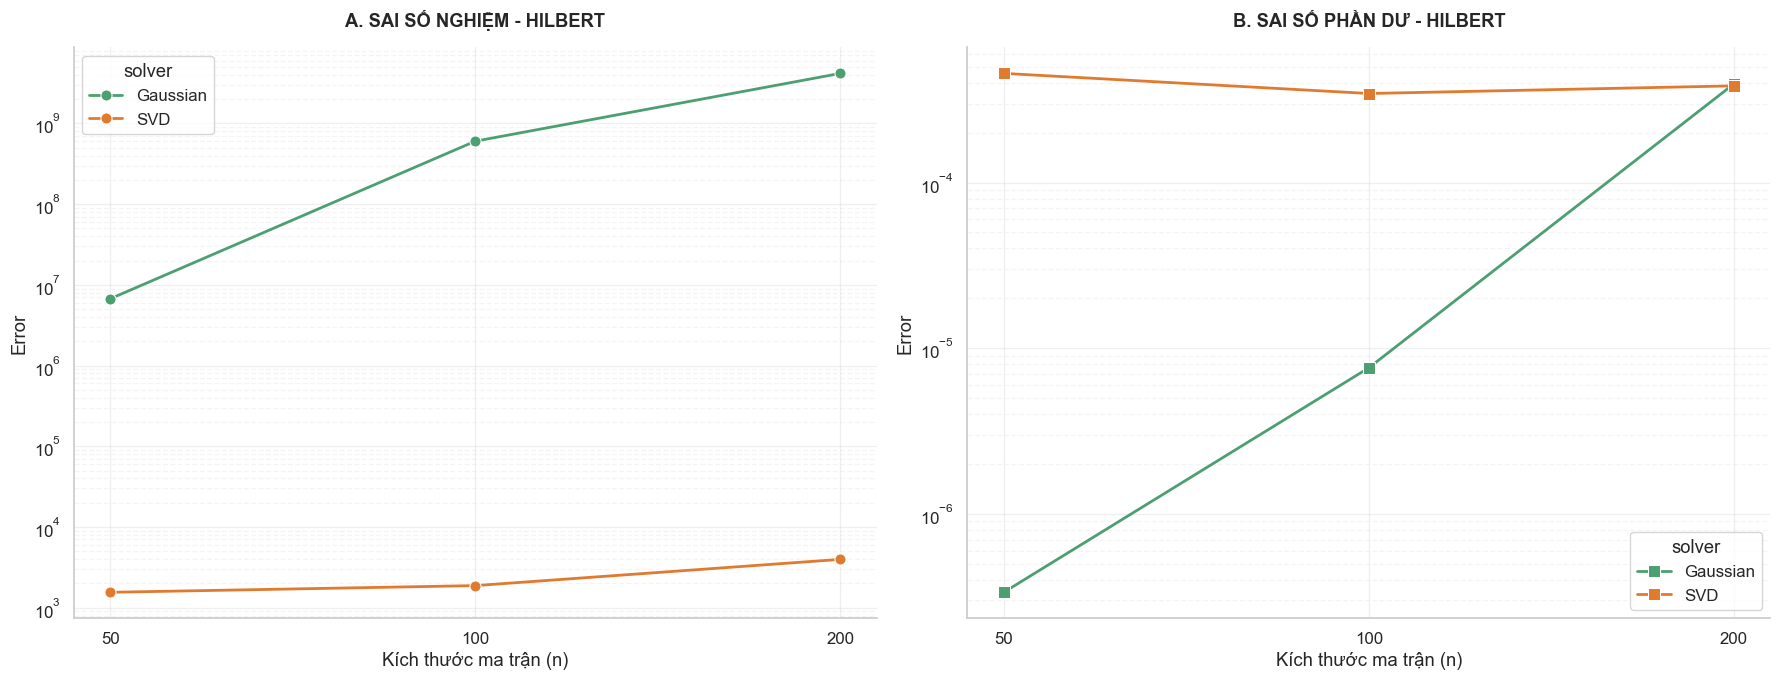

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('results.csv')

df_hilbert = df[
    (df['matrix_type'] == 'Hilbert') &
    (df['solver'].isin(['Gaussian', 'SVD']))
].copy()

df_hilbert = df_hilbert[
    (df_hilbert['n'] > 0) &
    (df_hilbert['solution_error'] > 0) &
    (df_hilbert['residual_error'] > 0)
]

df_hilbert['solver'] = df_hilbert['solver'].str.strip()

sns.set_theme(style="whitegrid", font_scale=1.1)

palette = {
    'Gaussian': '#4C9F70',
    'SVD': '#E07A2F'
}

hue_order = ['Gaussian', 'SVD']

n_values = sorted(df_hilbert['n'].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=df_hilbert,
    x='n',
    y='solution_error',
    hue='solver',
    hue_order=hue_order,
    palette=palette,
    marker='o',
    linewidth=2,
    markersize=8,
    ax=ax1
)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xticks(n_values)
ax1.set_xticklabels(n_values)

ax1.set_title('A. SAI SỐ NGHIỆM - HILBERT', fontweight='bold', pad=15)
ax1.set_xlabel('Kích thước ma trận (n)')
ax1.set_ylabel('Error')

ax1.grid(True, which="major", linestyle='-', alpha=0.3)
ax1.grid(True, which="minor", linestyle='--', alpha=0.2)

sns.lineplot(
    data=df_hilbert,
    x='n',
    y='residual_error',
    hue='solver',
    hue_order=hue_order,
    palette=palette,
    marker='s',
    linewidth=2,
    markersize=8,
    ax=ax2
)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xticks(n_values)
ax2.set_xticklabels(n_values)

ax2.set_title('B. SAI SỐ PHẦN DƯ - HILBERT', fontweight='bold', pad=15)
ax2.set_xlabel('Kích thước ma trận (n)')
ax2.set_ylabel('Error')

ax2.grid(True, which="major", linestyle='-', alpha=0.3)
ax2.grid(True, which="minor", linestyle='--', alpha=0.2)

ax1.legend(title='solver')
ax2.legend(title='solver')
ax1.set_xticks(n_values)
ax1.set_xticklabels(n_values)
ax1.xaxis.set_minor_locator(plt.NullLocator())

ax2.set_xticks(n_values)
ax2.set_xticklabels(n_values)
ax2.xaxis.set_minor_locator(plt.NullLocator())
sns.despine()
plt.tight_layout()
plt.show()

Trong khi ở ma trận SPD, hai thuật toán này duy trì độ chính xác tuyệt vời, thì trên ma trận Hilbert, chúng bộc lộ rõ giới hạn của mình. Biểu đồ trên đây theo dõi mức độ khuếch đại sai số khi hệ điều kiện $\kappa(A)$ tăng dần theo $n$.

Thông thường, chúng ta kỳ vọng rằng nếu nghiệm $\hat{x}$ thỏa mãn tốt phương trình ($r = \|A\hat{x} - b\|$ nhỏ) thì $\hat{x}$ phải gần với nghiệm thực $x$. Tuy nhiên, biểu đồ đối chiếu giữa Residual Error và Solution Error cho thấy:
- Sai số nghiệm (Biểu đồ A) đã bùng nổ theo hàm mũ.
- Đây là hệ quả trực tiếp của Số điều kiện (Condition Number - $\kappa(A)$). Với ma trận Hilbert $n=200$, $\kappa(A)$ vượt xa ngưỡng $10^{16}$. Theo bất đẳng thức cơ bản của giải tích số:
$$\frac{\|\Delta x\|}{\|x\|} \le \kappa(A) \frac{\|\Delta b\|}{\|b\|}$$
Một sai số phần dư nhỏ ($\approx 10^{-6}$) khi đi qua "bộ khuếch đại" $\kappa(A) \approx 10^{15}$ sẽ ngay lập tức tạo ra sai số nghiệm khổng lồ ($\approx 10^9$).
-
**1.Sự bùng nổ về sai số của Gauss (Gaussian Elimination):**
- Sai số của Khử Gauss vọt lên mức $10^{8} - 10^{10}$ ngay khi $n$ tiến dần đến 200.
- Nguyên nhân: Ma trận Hilbert làm các phần tử chốt (pivots) trở nên cực nhỏ. Phép chia cho các số chốt này khuếch đại các sai số làm tròn nhỏ nhất từ mức Machine Epsilon($\epsilon \approx 2.22 \times 10^{-16}$) lên thành các con số khổng lồ, phá hủy hoàn toàn tính đúng đắn của nghiệm.

**2.Sự chênh lệch giữ lý thuyết và thực tiễn mã nguồn của SVD trên Hillbert:**

Dù được xem là "Tiêu chuẩn vàng" về độ ổn định với các phép biến đổi trực giao đẳng cự ($\kappa = 1$), toàn bộ dữ liệu thực nghiệm lại phơi bày một nghịch lý: Mã nguồn SVD tự triển khai đã thất bại trong việc tái hiện sức mạnh lý thuyết này. Sự đứt gãy này được minh chứng qua ba khía cạnh:
- Lỗ hổng từ Hiệp phương sai $A^T A$: Việc cài đặt thuật toán Jacobi bắt đầu bằng lệnh ATA = multiply(AT, A) là một sai lầm, thao tác này lập tức bình phương số điều kiện của hệ thống: $\kappa(A^T A) = \kappa^2(A)$ (từ $10^{19}$ lên $10^{38}$) vượt quá xa giới hạn $\approx 10^{16}$ của Float64. Toàn bộ các phần tử ngoài đường chéo lập tức bị tràn số dưới (Underflow) và biến thành $0$. Điều kiện dừng if max_val < 1e-10: break bị đánh lừa và ngay lập tức thoát ra và trả về kết quả "rác" trong khi thực tế nó chưa kịp thực hiện bất kỳ phép quay Jacobi có nghĩa nào.
- Vì thuật toán thoát sớm do Underflow, ma trận $\Sigma$ (trị riêng) mà bạn thu được chứa các giá trị ảo do rác số học tạo ra. Khi thực hiện bước giải nghiệm $x = V \Sigma^{-1} U^T b$, việc nghịch đảo các giá trị $\sigma_i$ siêu nhỏ (nhưng thực tế là sai lệch) đã thổi phồng Sai số nghiệm lên hàng ngàn lần (lên tới $3968.72$ cho $N=200$).

Phân tích SVD trên hệ Hilbert bộc lộ trạng thái nguy hiểm nhất của giải tích số: Sự hội tụ giả định. Do số điều kiện bùng nổ vượt quá giới hạn biểu diễn của Float64 ($10^{38} \gg 10^{16}$), các thành phần thông tin của ma trận Hilbert bị triệt tiêu ngay trong pha tính toán hiệp phương sai sơ khởi. Kết quả là thuật toán thoát sớm với trạng thái 'Thành công' ảo tưởng, tạo ra một vector nghiệm sai lệch nghiêm trọng ($3968.72$) mặc dù phần dư vẫn nằm trong ngưỡng chấp nhận được. Thực nghiệm này là lời cảnh báo đanh thép: Trên các hệ thống siêu suy biến, tính ổn định lý thuyết của SVD hoàn toàn bị vô hiệu hóa nếu quy trình thực thi không bảo toàn được số lượng chữ số có nghĩa (significant digits) trước các cú sốc Underflow.

**3.Tác động của Hệ điều kiện ($\kappa(A)$):**

Biểu đồ này là minh chứng thực nghiệm cho việc:
- Chỉ số Residual là không đủ: Trong các bài toán thực tế có độ nhạy cảm cao, một phần dư nhỏ là điều kiện cần nhưng không đủ để bảo chứng cho tính đúng đắn của nghiệm.
- Sự sụp đổ của Float64: Ma trận Hilbert không chỉ thử thách thuật toán mà còn thử thách chính hệ thống số thực dấu phẩy động. Kết quả $10^9$ của Khử Gauss là một cảnh báo về việc "nhiễu số học" đã chiếm quyền kiểm soát hoàn toàn hệ thống.
- Khử Gauss thất bại vì tự sinh ra rác số học. SVD thất bại dù đã dọn sạch rác, bởi nó không thể chống lại định luật khuếch đại toán học. Qua đó, ta thấy SVD là một 'tấm khiên' tuyệt vời bảo vệ thuật toán khỏi nhiễu nội sinh, nhưng không một tấm khiên nào che chắn được sự suy biến thông tin áp đặt bởi chính ($\kappa(A)$ của không gian dữ liệu

## Phương pháp lặp Gauss-Seidel trong ma trận Hillbert: Hiện tượng Trì trệ (Stagnation)

Trong khi các phương pháp trực tiếp thất bại bằng sự bùng nổ sai số (Error Explosion), phương pháp lặp Gauss-Seidel lại bộc lộ một trạng thái bệnh lý tinh vi hơn: Sự trì trệ số học (Numerical Stagnation). Đối với một ma trận "độc hại" như ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$) hoàn toàn gần như không thể hội tụ thì thuật toán Gauss-Seidel chắc chắn sẽ cho ra kết quả Failed.

Trong code solvers.py đã thiết lập một cơ chế kiểm tra hai lớp. Tuy nhiên, chính cơ chế này lại là "kẻ tiếp tay" cho việc báo cáo sai kết quả trên hệ Hilbert.

**1.Sự thất bại của Gauss-Seidel trên hệ Hilbert xuất phát từ việc lạm dụng tiêu chuẩn dừng dựa trên bước nhảy (Step-size)**
```
err_sq: float = 0.0
for i in range(n):
    old_xi: float = x[i]
    # ... tính x[i] mới ...
    diff: float = x[i] - old_xi
    err_sq += diff**2

err: float = math.sqrt(err_sq) # Tính chuẩn L2 của vector khoảng cách
if err < tolerance:            # Đây chính là Cửa 1
```
Ta có thể xem cửa 1 này đóng vai trò như một bộ cảm biến chuyển động. Nó đặt ra câu hỏi: "Sau một vòng tính toán vất vả, kết quả mới có khác gì nhiều so với kết quả cũ không?"
- Nếu khác nhiều (err >= tolerance): Thuật toán nghĩ: "Nghiệm vẫn đang 'chạy' rất hăng hái để tìm đích, chưa dừng lại được." $\to$ Tiếp tục vòng lặp.
- Nếu khác rất ít (err < tolerance): Thuật toán nghĩ: "Nghiệm gần như đã đứng yên rồi, chắc là nó đã tìm thấy kết quả." $\to$ Cho phép bước vào Cửa 2 để kiểm tra phần dư.

Đoạn code này đang sử dụng Chuẩn L2 của hiệu hai vector liên tiếp để đo lường khoảng cách hình học thực sự mà nghiệm đã di chuyển được:$$err = \|x^{(k+1)} - x^{(k)}\|_2 = \sqrt{\sum_{i=1}^n \left(x_i^{(k+1)} - x_i^{(k)}\right)^2} < tolerance$$
Nó đo lường "quãng đường" mà nghiệm di chuyển được sau một vòng lặp. VÌ vậy nếu quãng đường này quá ngắn (nhỏ hơn tolerance), thuật toán giả định rằng nó đã tiến sát đến nghiệm cuối cùng.

Tuy nhiên đối với ma trận Hilbert,tốc độ hội tụ quá chậm, hiệu số giữa hai lần lặp liên tiếp nhỏ đi rất nhanh và rơi xuống dưới ngưỡng sai số cho phép trước khi nghiệm thực sự đạt tới độ chính xác yêu cầu hay có thể nói nghiệm di chuyển cực kỳ chậm: $x^{(k+1)} \approx x^{(k)}$. Khi đó:
- Code thấy err rất nhỏ (nhỏ hơn cả tolerance) và kết luận: "Đi qua cửa 1" hay thuật toán đã hội tụ
- Thực tế: Nghiệm chỉ đang "trì trệ" (stagnating) tại một điểm rất xa nghiệm đúng.

Vì vậy đã xảy ra tình trạng nhầm lẫn giữa việc code đã ngừng hoạt động với việc code ra kết quả. Vì hội tụ cực kỳ chậm nhưng bước nhảy vẫn lớn hơn tolerance, thuật toán sẽ chạy đến max_iter mà không bao giờ thèm ngó ngàng đến việc nghiệm đó đã giải đúng phương trình hay chưa và khi chạy hết max_iter = 100000 thì sẽ cho ra output. Mặc dù kết quả chạy là Success nhưng output lại là kết quả "rác" vì cách quá xa so với kết quả đúng

**2.Tiêu chuẩn dừng dựa trên Phần dư (Residual Criterion)**

Ngay sau khi bước nhảy err nhỏ hơn tolerance, code gọi hàm residual để kiểm chứng lại một lần cuối:
```
if err < tolerance:                 # Vượt qua Cửa 1
    res: float = residual(A, x, b)  # Gọi hàm kiểm tra chất lượng
    if res < tolerance:             # Đây là cửa 2
        return x                    # Chỉ khi vượt qua đây mới được coi là "Success"
```

Cửa 2 đóng vai trò là một bộ lọc chất lượng nghiệm, được kích hoạt ngay sau khi tiêu chuẩn bước nhảy (Cửa 1) thỏa mãn. Mục tiêu của nó là xác nhận tính đúng đắn của nghiệm $x$ dựa trên tính nhất quán của hệ phương trình gốc.

Cửa 2 là bộ lọc chất lượng dựa trên tính nhất quán của hệ phương trình gốc. Với chuẩn $L_2$, hàm residual sẽ đánh giá tổng năng lượng sai số của toàn bộ hệ thống:
$$r = \|Ax^{(k)} - b\|_2 = \sqrt{\sum_{i=1}^n \left( \sum_{j=1}^n A_{ij}x_j^{(k)} - b_i \right)^2}$$

Trong các hệ well-conditioned, chuẩn $L_2$ của phần dư là một thước đo vàng. Nếu $r < tolerance$, hệ thống chắc chắn đã ổn định. Tuy nhiên, khi đối mặt với Hilbert, nó hoàn toàn bị vô hiệu hóa bởi hằng số khuếch đại sai số $\kappa(A)$ khổng lồ.
Theo định lý nhiễu loạn trên chuẩn $L_2$:
$$\frac{\|\delta x\|_2}{\|x\|_2} \le \kappa_2(A) \cdot \frac{\|\delta A\|_2}{\|A\|_2}$$

Với $\kappa_2(A)$ của ma trận Hilbert $n=200$ lên tới $10^{18}$, một nhiễu cơ học vô cùng nhỏ ($\approx 10^{-16}$) có thể bị bẩy lên thành sai lệch khổng lồ. Dù có đo lường được phần dư rất nhỏ (ví dụ $10^{-7}$), thì Sai số nghiệm thực tế (Solution Error) vẫn có thể vọt lên $10^{18} \times 10^{-7} = 10^{11}$. Cơ chế dừng này không hề biết rằng nó đang nghiệm thu một kết quả đã bị lệch xa khỏi nghiệm thực tế.

**3.Sự thất bại của phép tính dấu phảy động (FLOP)**

Hàm residual thực thi trên CPU:
```
sum(A[i][j] * x[j] for j in range(n)) - b[i]
```
Trên hệ Hilbert $n=200$:
- Các $x_j$ do mất ổn định đã vọt lên $10^9$, trong khi $A_{ij} \approx 10^{-3}$. Kết quả phép nhân là $10^6$.
- Khi thực hiện tổng các số hạng $10^6$ rồi trừ đi $b_i$, các bit biểu diễn phần thập phân (precision bits) bị đẩy ra khỏi phạm vi của 64-bit.
- Kết quả trả về của residual lúc này không còn là sai số toán học thực sự nữa. Nó là nhiễu trắng (numerical noise) của chuẩn IEEE 754. Sai lầm ở đây là nhiễu này thường có giá trị nhỏ hơn $10^{-6}$, vô tình giúp nghiệm "lọt lưới" Cửa 2 và trả về trạng thái Success.
- Để tính chuẩn $L_2$, thuật toán phải bình phương các $r_i$ này lên ($r_i^2$). Việc bình phương một lượng nhiễu $10^{-8}$ sẽ ép nó rớt thẳng xuống $10^{-16}$. Hàng loạt các giá trị này lập tức bị CPU ép về $0$ do tràn số dưới (Underflow). Do đó khi lấy căn bậc hai của tổng các số $0$ (hoặc tiệm cận $0$), hàm residual trả về một con số cực kỳ nhỏ, dễ dàng chui lọt qua rào chắn tolerance của Cửa 2.

Từ những điều trên t có thể thấy điểm yếu trong code Solvers.py là Tính phụ thuộc tuần Cửa 2 chỉ được kiểm tra nếu Cửa 1 (err < tolerance) đã thông qua.

Điều này tạo ra một kịch bản "thất bại kép":
- Nghiệm di chuyển chậm (Trì trệ) $\rightarrow$ Vượt qua Cửa 1.
- Ma trận nén sai số làm tròn $\rightarrow$ Vượt qua Cửa 2.
- Hàm return x $\rightarrow$ Benchmark ghi nhận Success.

Từ đó ta có thể thấy Cửa 2 trong code hiện tại đang đóng vai trò là một "cơ chế bù nhìn". Trong khi thuật toán duy trì được một sai số residual nằm trong ngưỡng cho phép của số thực dấu phẩy động, thì số điều kiện $\kappa(A)$ quá lớn đã khuếch đại các nhiễu số học này thành một sai số solution khổng lồ.

Điều này khẳng định một nguyên lý cốt lõi: Với các hệ thống ill-conditioned cực đoan, việc dựa dẫm vào chuẩn $L_2$ của cả bước nhảy lẫn phần dư là một cái bẫy chết người. Nó biến hệ thống kiểm soát sai số thành một "cơ chế bù nhìn", cho phép cho những nghiệm rác vượt qua bài test và báo cáo thành công ảo tưởng. Dữ liệu tồi tệ đòi hỏi những cơ chế chẩn đoán phổ (spectral diagnostics) tinh vi hơn nhiều so với các phép đo khoảng cách hình học thuần túy.

